# 07 — 接触制約・摩擦・遊脚

## 目的
Gaitのboolが、NMPC内で「立脚の制約」と「遊脚の制約」を切替える仕組みを理解する。

実装対応:
- `legged_interface/constraint/`
- `SwingTrajectoryPlanner.cpp`
- `SwitchedModelReferenceManager.cpp`


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
print("repository:", ROOT)


repository: /home/takuya/work/mpc_dog


脚 \(i\) ごとの主要条件:

- 遊脚: \(f_i=0\)
- 立脚: 足速度0
- 遊脚: plannerが与える法線方向速度
- 立脚摩擦（NMPC soft constraint）:
  \[
  \mu(F_z+F_g)-\sqrt{F_x^2+F_y^2+\varepsilon}\ge0
  \]
- 自己衝突距離 \(\ge 0.05\) m

A1既定 \(\mu=0.3\)。地形法線のsetterは現行実装で未実装例外、
reference managerは地形高さ0を渡すため、知覚不整地NMPCではない。


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20870 (\N{CJK UNIFIED IDEOGRAPH-5186}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20596 (\N{CJK UNIFIED IDEOGRAPH-5074}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWar

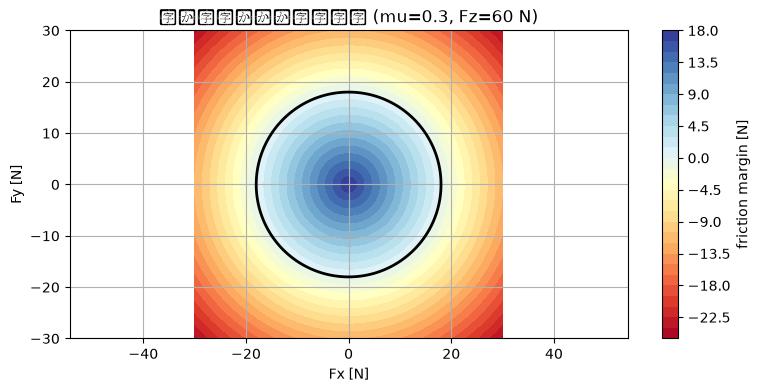

In [2]:
# 摩擦円錐の余裕 margin = mu*Fz - ||Ft|| を計算する。
def friction_margin(force, mu=0.3):
    force = np.asarray(force)
    return mu*force[...,2] - np.linalg.norm(force[...,:2], axis=-1)

Fz = 60.0
fx = np.linspace(-30, 30, 161)
fy = np.linspace(-30, 30, 161)
FX, FY = np.meshgrid(fx, fy)
M = 0.3*Fz - np.sqrt(FX**2 + FY**2)
filled = plt.contourf(FX, FY, M, levels=30, cmap="RdYlBu")
plt.contour(FX, FY, M, levels=[0], colors="k", linewidths=2)
plt.colorbar(filled, label="friction margin [N]")
plt.xlabel("Fx [N]"); plt.ylabel("Fy [N]")
plt.title("円の内側だけが実行可能 (mu=0.3, Fz=60 N)")
plt.axis("equal"); plt.show()


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarn

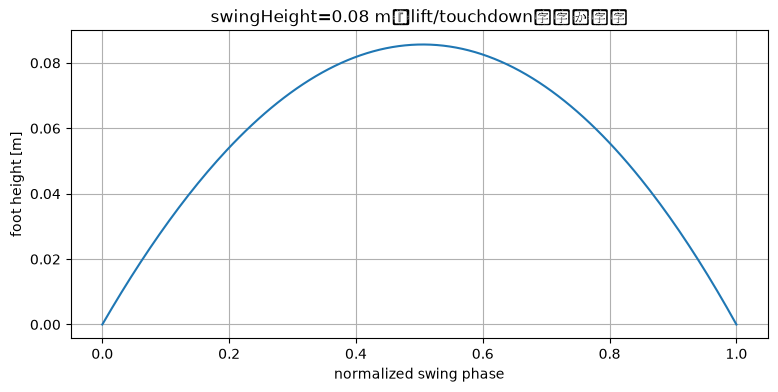

In [3]:
# 境界速度を指定した三次Hermite遊脚高さ。実装はspline CPGを使う。
def hermite_z(s, z0=0.0, z1=0.0, v0=0.05, v1=-0.10, duration=0.3):
    h00 = 2*s**3 - 3*s**2 + 1
    h10 = s**3 - 2*s**2 + s
    h01 = -2*s**3 + 3*s**2
    h11 = s**3 - s**2
    return h00*z0 + h10*duration*v0 + h01*z1 + h11*duration*v1

s = np.linspace(0, 1, 200)
z_base = hermite_z(s)
# 中間liftを加える教育用bump
z = z_base + 0.08 * 4*s*(1-s)
plt.plot(s, z)
plt.xlabel("normalized swing phase"); plt.ylabel("foot height [m]")
plt.title("swingHeight=0.08 m、lift/touchdown速度の意味")
plt.show()


## NMPCとWBCで摩擦形状が違う
NMPCは正則化した円錐のsoft constraint。WBCは
\(|F_x|\le\mu F_z, |F_y|\le\mu F_z, F_z\ge0\) の線形pyramid。
同じ \(\mu=0.3\) でも実行可能集合は一致しない。この差を無視して
「NMPCでfeasibleだからWBCもfeasible」とは言えない。

### 変更課題
\(\mu\) を上げて歩けた結果は、摩擦推定が改善した証拠ではない。
実床の摩擦より大きくすると、存在しない横力を計画する。推定値、slip率、
friction margin、WBC再配分を一緒に確認する。


## 章固有の背景
                同じ足でも立脚中は地面拘束、遊脚中は力ゼロと軌道追従へ役割が切り替わる。

                ## 章固有の目的
                ModeScheduleから各足の等式・摩擦不等式・swing targetがactivateされる経路を読む。

                ## この章のASCIIデータフロー
                ```text
                ModeSchedule -> contact flag -> stance: foot velocity=0, friction
                            \-> swing: force=0, spline velocity/height
terrain height(既定0) -> SwingTrajectoryPlanner
                ```

                ## 上流C++ / faithful pseudocode と数式の行対応
                ```cpp
                // external/legged_control/legged_interface constraint activation
isActive(t) = !contactFlag[i]; // ZeroForceConstraint: swingなら f_i=0
isActive(t) =  contactFlag[i]; // ZeroVelocityConstraint: stanceなら v_foot=0
// FrictionConeConstraint
h = mu*(Fz+Fg)-sqrt(Fx*Fx+Fy*Fy+eps); // h>=0
// SwingTrajectoryPlanner.cpp
swingHeight = 0.08;                   // task.info
z(t)=spline(position, liftOffVelocity, touchDownVelocity); // 遊脚法線軌道
                ```

                **事実のラベル**: `external/legged_control/` の記述はcommit
                `a7f381c0367e98e31c01336e678eef47e304d40d` の上流実装事実。数式展開はそのinterfaceを説明する理論。
                `src/legged_control_mujoco/` に言及した行はproject所有adapterの実装であり、
                ROS1/OCS2 SQP原実装とは同一ではない。

                ## 章固有の結論
                NMPCのsoft円錐とWBCのhard pyramidは異なる集合である。地形法線setter未実装の上流既定を知覚歩行と誤認しない。
